# Generated-data visualisation

Inspects a raw generated dataset (from `generate_data.py`) before running
either inference pipeline on it: single-shot images (ground/excited state
counts per pixel), the ground-state-fraction map and its Z100-Z0
differential, and the port-count "fringe ellipse" across shots. Useful for
sanity-checking a newly-generated dataset (does it look like a Gaussian
cloud, is the fringe visible/reasonable contrast, does phi0 vary shot to
shot as expected) before trusting downstream fits.

Point `DATA_DIR`/`RUN` at any dataset under `data/` -- defaults to the
1e6-atom non_phase_shear dataset, `run_000` (guaranteed present after
`download_data.sh`). Try one of the `phase_shear` (`..._kappa...`)
datasets too to see the injected wavefront ramp's effect on the fringe.

In [1]:
import sys, os
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO / 'helpers'))
from helpers import ImageShotDataset

DATA_DIR = REPO / 'data' / (
    'R80_N200_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um_'
    'sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000'
)
RUN = 'run_000'

In [2]:
Z0   = ImageShotDataset(str(DATA_DIR / RUN / 'Z0'   / 'data_IMG.h5'))
Z100 = ImageShotDataset(str(DATA_DIR / RUN / 'Z100' / 'data_IMG.h5'))

with h5py.File(Z0.path) as f:
    signal_amp   = float(f.attrs['signal_amp'])
    signal_freq  = float(f.attrs['signal_freq'])
    signal_phase = float(f.attrs['signal_phase'])

print(f'{Z0.n_shots} shots,  {Z0.n_atoms_launched:,} atoms launched/shot')
print(f'Image: {Z0.res}x{Z0.res}  window +/-{Z0.half_range*1e3:.0f}mm  pixel={Z0.pixel_size*1e6:.1f}um')
print(f'phi0 range: [{Z0.phi0.min():.2f}, {Z0.phi0.max():.2f}] rad')
print(f'signal: amp={signal_amp:.3f} rad  freq={signal_freq:.4f} cyc/shot  phase={signal_phase:.3f} rad')
print(f'Detection efficiency -- Z0: {Z0.detection_efficiency():.3f}  Z100: {Z100.detection_efficiency():.3f}')

200 shots,  1,000,000 atoms launched/shot
Image: 2048x2048  window +/-3mm  pixel=2.9um
phi0 range: [0.04, 6.28] rad
signal: amp=0.100 rad  freq=0.3000 cyc/shot  phase=0.500 rad


Detection efficiency -- Z0: 0.909  Z100: 0.763


Shot 5: 788,292 ground  |  124,275 excited  |  total 912,567
phi0 = 4.072 rad


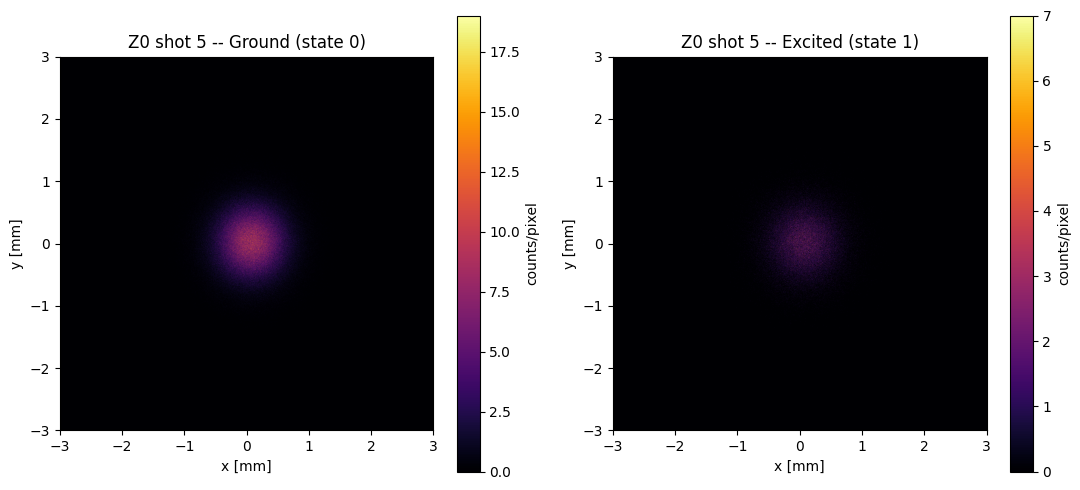

In [3]:
idx = 5
img = Z0[idx]   # shape (2, res, res)  --  img[0]=state0, img[1]=state1
lim = Z0.half_range * 1e3   # mm

n_s0 = int(img[0].sum())
n_s1 = int(img[1].sum())
print(f'Shot {idx}: {n_s0:,} ground  |  {n_s1:,} excited  |  total {n_s0+n_s1:,}')
print(f'phi0 = {Z0.phi0[idx]:.3f} rad')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
extent = [-lim, lim, -lim, lim]

for ax, state_img, label in zip(axes, img, ['Ground (state 0)', 'Excited (state 1)']):
    im = ax.imshow(state_img.T, origin='lower', extent=extent, cmap='inferno', aspect='equal')
    plt.colorbar(im, ax=ax, label='counts/pixel')
    ax.set_title(f'Z0 shot {idx} -- {label}')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2563073/2124347457.py:9: RuntimeWarning: invalid value encountered in divide
  frac_z0   = np.where(total_z0   > 0, img_z0[0]   / total_z0,   np.nan)
/tmp/ipykernel_2563073/2124347457.py:10: RuntimeWarning: invalid value encountered in divide
  frac_z100 = np.where(total_z100 > 0, img_z100[0] / total_z100, np.nan)


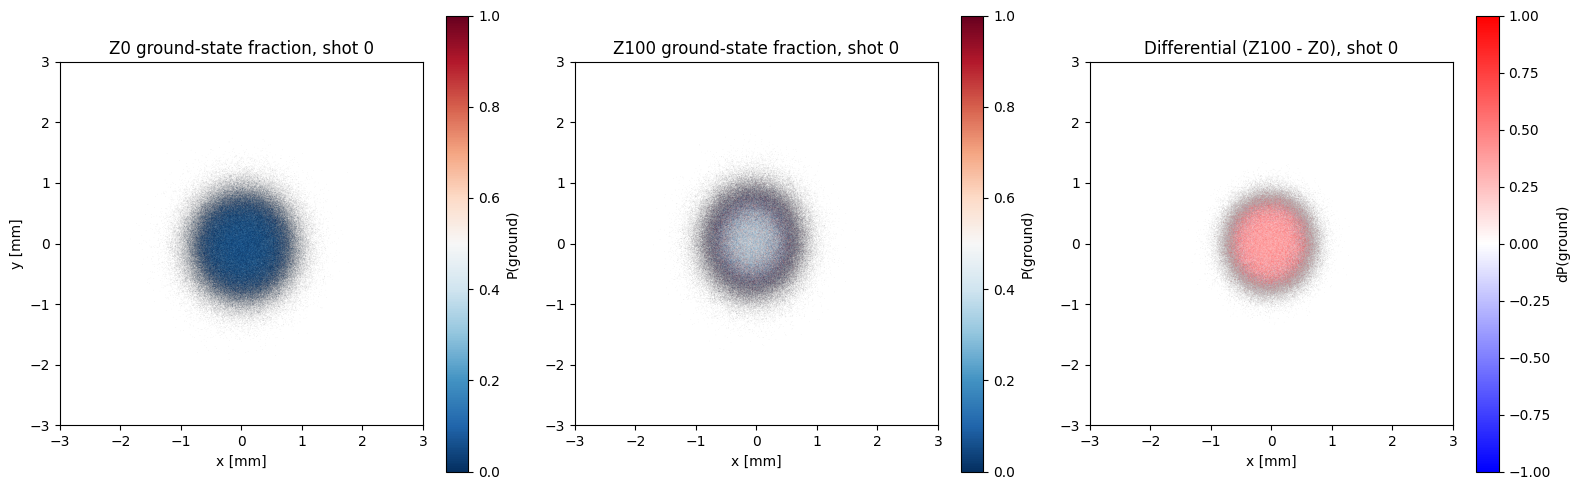

In [4]:
idx = 0
img_z0   = Z0[idx]    # (2, res, res)
img_z100 = Z100[idx]

# Total counts per pixel (s0 + s1) and local ground-state fraction
total_z0   = img_z0[0].astype(float)   + img_z0[1].astype(float)
total_z100 = img_z100[0].astype(float) + img_z100[1].astype(float)

frac_z0   = np.where(total_z0   > 0, img_z0[0]   / total_z0,   np.nan)
frac_z100 = np.where(total_z100 > 0, img_z100[0] / total_z100, np.nan)
diff_frac  = frac_z100 - frac_z0   # differential ground-state fraction

extent = [-lim, lim, -lim, lim]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(frac_z0.T, origin='lower', extent=extent,
                     vmin=0, vmax=1, cmap='RdBu_r', aspect='equal')
plt.colorbar(im0, ax=axes[0], label='P(ground)')
axes[0].set_title(f'Z0 ground-state fraction, shot {idx}')
axes[0].set_xlabel('x [mm]'); axes[0].set_ylabel('y [mm]')

im1 = axes[1].imshow(frac_z100.T, origin='lower', extent=extent,
                     vmin=0, vmax=1, cmap='RdBu_r', aspect='equal')
plt.colorbar(im1, ax=axes[1], label='P(ground)')
axes[1].set_title(f'Z100 ground-state fraction, shot {idx}')
axes[1].set_xlabel('x [mm]')

vmax = np.nanpercentile(np.abs(diff_frac), 99)
im2 = axes[2].imshow(diff_frac.T, origin='lower', extent=extent,
                     vmin=-vmax, vmax=vmax, cmap='bwr', aspect='equal')
plt.colorbar(im2, ax=axes[2], label='dP(ground)')
axes[2].set_title(f'Differential (Z100 - Z0), shot {idx}')
axes[2].set_xlabel('x [mm]')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2563073/179991276.py:10: RuntimeWarning: invalid value encountered in divide
  fringe_z0   = g_z0   / (g_z0   + e_z0)
/tmp/ipykernel_2563073/179991276.py:11: RuntimeWarning: invalid value encountered in divide
  fringe_z100 = g_z100 / (g_z100 + e_z100)


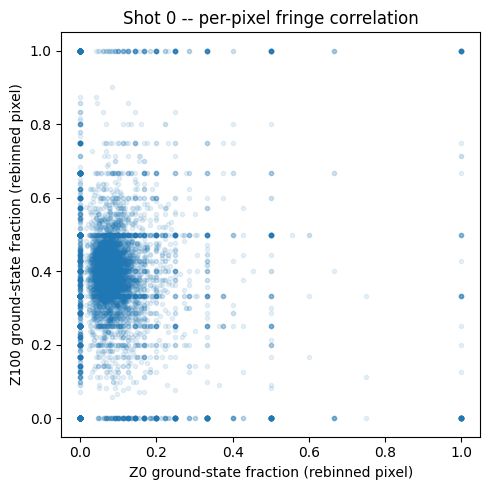

In [5]:
# Rebinned fringe scatter: ground-state fraction per (rebinned) pixel, Z0 vs Z100
def rebin_image(img, factor):
    """Rebin a 2D image by averaging over non-overlapping blocks of size factor x factor."""
    shape = (img.shape[0]//factor, factor, img.shape[1]//factor, factor)
    return img.reshape(shape).mean(-1).mean(1)

g_z0,   e_z0   = rebin_image(img_z0[0],   factor=8), rebin_image(img_z0[1],   factor=8)
g_z100, e_z100 = rebin_image(img_z100[0], factor=8), rebin_image(img_z100[1], factor=8)

fringe_z0   = g_z0   / (g_z0   + e_z0)
fringe_z100 = g_z100 / (g_z100 + e_z100)

plt.figure(figsize=(5, 5))
plt.plot(fringe_z0.flatten(), fringe_z100.flatten(), '.', alpha=0.1)
plt.xlabel('Z0 ground-state fraction (rebinned pixel)')
plt.ylabel('Z100 ground-state fraction (rebinned pixel)')
plt.title(f'Shot {idx} -- per-pixel fringe correlation')
plt.tight_layout()
plt.show()

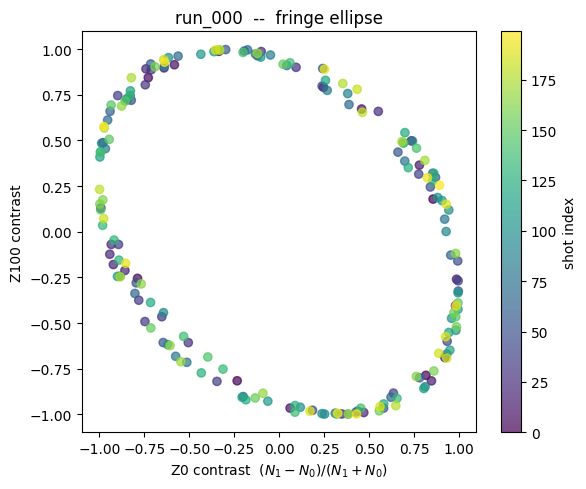

In [6]:
# Port-count "fringe ellipse" across all shots: (Z0 contrast, Z100 contrast)
n_z0   = Z0.state_counts()    # DataFrame columns {0: ground, 1: excited}
n_z100 = Z100.state_counts()

nground_z0,  nexcited_z0  = n_z0[0],  n_z0[1]
nground_z100, nexcited_z100 = n_z100[0], n_z100[1]

diff0   = (nexcited_z0   - nground_z0)   / (nexcited_z0   + nground_z0)
diff100 = (nexcited_z100 - nground_z100) / (nexcited_z100 + nground_z100)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(diff0, diff100, alpha=0.7, c=np.arange(len(diff0)), cmap='viridis')
plt.colorbar(sc, ax=ax, label='shot index')
ax.set_xlabel(r'Z0 contrast  $(N_1 - N_0)/(N_1 + N_0)$')
ax.set_ylabel('Z100 contrast')
ax.set_title(f'{RUN}  --  fringe ellipse')
plt.tight_layout()
plt.show()